## **README: Napari Image Processing Pipeline**

Loads a raw calcium-imaging timelapse (`.imgdir` frame dump), previews it in
napari, runs a lazy (dask-backed) denoise → background-normalise →
motion-correct pipeline, then supports manual ROI drawing (napari Labels layer,
saved/loaded as `.tiff`) and per-ROI brightness → dF/F trace extraction (§4).

### **1. Dependencies**

Run this notebook with the **`cascade` conda environment**
(`/Users/leolopster/miniconda3/envs/cascade`), which already provides every
package used here — it is *not* the `cascadetorch-env` from the repo's
`environment.yml`. Select that env's Python (or its Jupyter kernel) when
running:

```
conda activate cascade
```

- `napari` (+ Qt backend) — interactive viewer
- `dask` — lazy/out-of-core array stacking (`dask.array`, `dask.delayed`)
- `scikit-image` — `skimage.registration.phase_cross_correlation`;
  `skimage.restoration.denoise_nl_means` / `estimate_sigma` (denoise
  method `"nlm"`)
- `scipy` — `scipy.ndimage.gaussian_filter` (denoise method `"gaussian"`),
  `scipy.ndimage.shift`, `scipy.ndimage.percentile_filter` (dF/F baseline),
  `scipy.fft.dctn`/`idctn` (denoise method `"dct"`)
- `tifffile` — STD projection + ROI-mask `.tiff` I/O (§4)
- `zarr` — chunked on-disk store for the saved preprocessed stack (§3)
- `PyYAML` — parse `ElapsedTimes.yaml` for the real acquisition time axis
- `numpy`, `matplotlib` — array handling and static plotting
- `tqdm` *(optional)* — trace-extraction progress bar; degrades gracefully

Run in **JupyterLab/Notebook with the `%gui qt6` magic**, which starts a Qt
event loop so the napari window stays interactive alongside the notebook.

### **2. Usage / steps**

Run cells top to bottom; each section builds on viewer/array state from the
previous one.

1. **Create napari instance** — `%gui qt6`, then `napari.Viewer()` opens the
   viewer window (`viewer`).
2. **Open files** — point `data_dir` at a SlideBook-style `*.imgdir` export
   (see §3), glob `ImageData_Ch0_TP*.npy` in timepoint order, and load the
   first frame directly with `viewer.add_image()` as a sanity check.
   - **Max projection**: a plain-Python loop takes an elementwise max across
     every frame (loads each fully into memory, one at a time) and plots it
     with matplotlib for a quick static preview.
   - **Lazy stack**: wraps each frame load in `dask.delayed` and
     `da.stack`s them into one `(n_timepoints, height, width)` dask array
     (`raw_stack`) *without* reading the data.
3. **Preprocessing** — chained lazily per-frame so the full stack is never
   materialized at once (files can exceed RAM): denoise (`DENOISE_METHOD`) →
   background-normalise (`BACKGROUND_PERCENTILE`) → rigid motion correction.
   Result (`preprocessed_stack`) is added to napari; a max projection is
   plotted for QC.
   - **Save / load**: `preprocessed_stack` can be streamed to a chunked Zarr
     store under `_preprocessed/`; in later sessions run the load cell instead
     of the denoising cell to skip preprocessing entirely.
4. **ROI selection & trace extraction** — manual, napari-Labels-based:
   1. **STD projection** — `preprocessed_stack[::5].std(axis=0)` highlights
      temporally-fluctuating (active) pixels; added as `"preprocessed_std"`,
      saved to `_projections/`, and histogrammed for QC. Reference layer for
      drawing.
   2. **ROI mask (create / load / save)** — three independent cells on a
      napari **Labels** layer (`viewer.add_labels`): (a) create a blank layer
      and hand-paint ROIs with the brush tool; (b) load an existing mask from
      `_labels/<tag>_ROI.tiff`; (c) save the current layer back to `.tiff`.
   3. **Brightness traces** — per-ROI mean-intensity trace over the full time
      axis, streamed one dask frame at a time; time axis in seconds from
      `ElapsedTimes.yaml`.
   4. **dF/F + QC plots** — dF/F via a rolling low-percentile baseline
      (`BASELINE_PERCENTILE`, `BASELINE_WINDOW_S`), shown as (A) a dF/F
      spectrograph (ROI × time heatmap, `magma`) and (B) tightly-stacked
      per-ROI dF/F line charts.
   - *Not yet implemented (stubs):* PCA grouping (v) and PCA-distance graph
     (vi).

### **3. Image format**

- **Input**: a SlideBook-exported `*.imgdir` directory containing
  `ImageData_Ch0_TP########.npy` (one file per timepoint, shape `(1, H, W)`,
  `uint16`; observed `(1024, 1376)` after dropping the plane axis), per-frame
  `HistogramData_*` (unused), and `*.yaml` metadata. `ElapsedTimes.yaml` (a
  leading frame-count entry, then per-frame elapsed times in ms) *is* parsed in
  §4 to build the seconds time axis; the rest are not.
- **In-memory/lazy**: raw and preprocessed stacks are dask arrays of shape
  `(n_timepoints, height, width)`, chunked one frame at a time; preprocessing
  casts to `float32`.

### **4. Output format**

- **Persisted to disk**:
  - `_preprocessed/<tag>_<method>.zarr` (+ a `.params.json` sidecar) — the full
    preprocessed stack (§3), streamed one frame per chunk. Lets future sessions
    skip the denoise+motion-correction step via the §3 load cell.
  - `_projections/<tag>_std_projection.tiff` — STD projection of the
    preprocessed stack (`tifffile`, §4).
  - `_labels/<tag>_ROI.tiff` — hand-drawn ROI Labels mask (`uint16`,
    `tifffile`, §4), the round-trip artifact for manual ROI selection.
- **In-memory only**: `raw_stack`, per-ROI `roi_traces` and `dff_traces`.
- Static QC figures (max/STD projections, STD histogram, dF/F spectrograph,
  stacked dF/F traces) are rendered inline via matplotlib, not saved to file.
- No spike-inference step is run here — it only prepares the imaging stack and
  per-ROI traces. Per `CLAUDE.md`, keep raw and processed data separate from any
  later inferred-spike output, and log preprocessing parameters (`DENOISE_METHOD`
  + method-specific params, `BACKGROUND_PERCENTILE`, and the §4
  `BASELINE_PERCENTILE` / `BASELINE_WINDOW_S`) alongside saved results.

## **1. Create Napari instance**

In [1]:
# Open GUI magic command
%gui qt6

In [2]:
# Open napari
from skimage import data
import napari

viewer = napari.Viewer()

In [3]:
# Visualising images using matplotlib
import matplotlib.pyplot as plt

## **2. Open Files**

**Directory:**

`/Users/leolopster/Desktop/spike_inference/leftDRGcut-1769167239-383.imgdir`
`/Users/leolopster/Desktop/spike_inference/Debi_DRG-Streamtodisk-1769166699-997.imgdir`

### **Loader**

In [4]:
# Load the first image file
from pathlib import Path
import numpy as np

# Unused data directory
# data_dir = Path("/Users/leolopster/Desktop/spike_inference/leftDRGcut-1769167239-383.imgdir")

data_dir = Path("/Users/leolopster/Desktop/spike_inference/Debi_DRG-Streamtodisk-1769166699-997.imgdir")
image_files = sorted(data_dir.glob("ImageData_Ch0_TP*.npy"))
print(f"Found {len(image_files)} timepoints")

first_frame = np.load(image_files[0])[0]  # drop the singleton plane axis
print(first_frame.shape, first_frame.dtype)

# Visualise the first image file
viewer.add_image(first_frame, name="frame_0000")

Found 3220 timepoints
(1024, 1376) uint16


<Image layer 'frame_0000' at 0x108346b00>

In [5]:
# Load the filestack with lazy loading enabled
import dask
from dask import delayed
import dask.array as da

@delayed
def load_frame(path):
    return np.load(path)[0]


frame_shape = first_frame.shape
frame_dtype = first_frame.dtype

lazy_frames = [
    da.from_delayed(load_frame(f), shape=frame_shape, dtype=frame_dtype)
    for f in image_files
]
raw_stack = da.stack(lazy_frames, axis=0)
print(raw_stack)  # (n_timepoints, height, width) -- not yet loaded into memory

viewer.add_image(raw_stack, name="raw_stack")

dask.array<stack, shape=(3220, 1024, 1376), dtype=uint16, chunksize=(1, 1024, 1376), chunktype=numpy.ndarray>


<Image layer 'raw_stack' at 0x3100db670>

### **Max Projection (Test Visuals)**

In [6]:
# Produce a max-stacked image from raw dataset
original_max_stack = np.zeros(first_frame.shape, dtype=first_frame.dtype)
for f in image_files:
    frame = np.load(f)[0]
    np.maximum(original_max_stack, frame, out=original_max_stack)

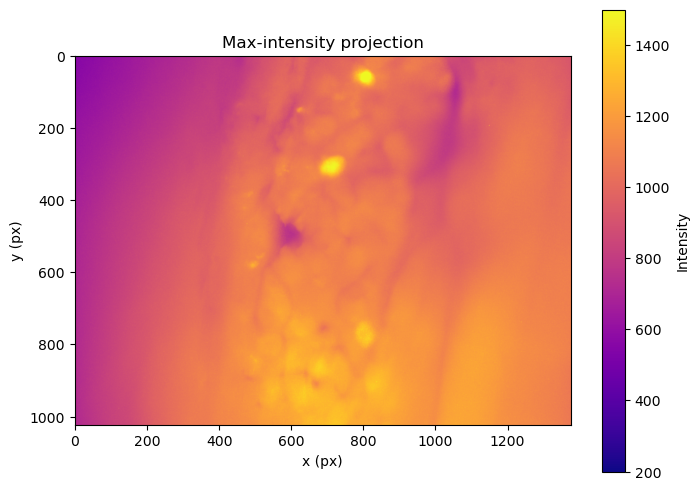

In [7]:
# Plot Figure
plt.figure(figsize=(8, 6))
plt.imshow(original_max_stack, cmap="plasma", vmin=200, vmax=1500)
plt.colorbar(label="Intensity")
plt.title("Max-intensity projection")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.show()

## **3. Preprocessing**

**Steps:**
1) Denoising — set `DENOISE_METHOD` to one of:
   - `"gaussian"` (default) — `scipy.ndimage.gaussian_filter`, `DENOISE_SIGMA`
   - `"nlm"` — non-local means, `skimage.restoration.denoise_nl_means`
     ([example](https://scikit-image.org/docs/stable/auto_examples/filters/plot_nonlocal_means.html)),
     noise level auto-estimated per-frame via `skimage.restoration.estimate_sigma`
   - `"dct"` — discrete cosine transform hard-thresholding via `scipy.fft.dctn`/`idctn`,
     `DCT_THRESHOLD_FRACTION`
2) Normalise to Background
3) Motion Correction

Note that files may be larger than RAM size.

### **Preprocess Settings**

In [8]:
# CONSTANTS
DENOISE_METHODS = ("gaussian", "nlm", "dct")
DENOISE_METHOD = "gaussian,nlm"  # comma separated methods, all indicated methods are used

DENOISE_SIGMA = 2.0  # gaussian

NLM_PATCH_SIZE = 5  # nlm: size (px) of patches used for patch distance comparison
NLM_PATCH_DISTANCE = 6  # nlm: max px distance to search for similar patches
NLM_H_FACTOR = 1.15  # nlm: cut-off distance, scaled by the estimated noise sigma

DCT_THRESHOLD_FRACTION = 0.0005  # dct: coefficients below this fraction of the max |coefficient| are zeroed

BACKGROUND_PERCENTILE = 6 # for normalisation

### **Run Denoising**

In [9]:
# Denoising, background normalisation and motion correction, chained lazily
# so the full (n_timepoints, height, width) stack is never held in RAM at once.
from scipy.ndimage import gaussian_filter, shift as nd_shift
from scipy.fft import dctn, idctn
from skimage.registration import phase_cross_correlation
from skimage.restoration import denoise_nl_means, estimate_sigma


def denoise_frame_gaussian(frame, sigma=DENOISE_SIGMA):
    return gaussian_filter(frame, sigma=sigma)


def denoise_frame_nlm(frame, patch_size=NLM_PATCH_SIZE, patch_distance=NLM_PATCH_DISTANCE, h_factor=NLM_H_FACTOR):
    # https://scikit-image.org/docs/stable/auto_examples/filters/plot_nonlocal_means.html
    sigma_est = estimate_sigma(frame, channel_axis=None)
    return denoise_nl_means(
        frame,
        h=h_factor * sigma_est,
        sigma=sigma_est,
        fast_mode=True,
        patch_size=patch_size,
        patch_distance=patch_distance,
        channel_axis=None,
    )


def denoise_frame_dct(frame, threshold_fraction=DCT_THRESHOLD_FRACTION):
    # Whole-frame 2D DCT. Hard-threshold small-magnitude AC coefficients
    # (high-frequency noise), then invert. The DC coefficient (frame mean
    # intensity) is excluded from the threshold scale and never dropped --
    # it's usually 100-1000x larger than any AC term, so including it made
    # the threshold zero out nearly the whole AC spectrum, collapsing the
    # frame to a flat constant.
    coeffs = dctn(frame, norm="ortho")
    ac_max = np.abs(coeffs.flat[1:]).max()
    threshold = threshold_fraction * ac_max
    mask = np.abs(coeffs) < threshold
    mask[0, 0] = False
    coeffs[mask] = 0
    return idctn(coeffs, norm="ortho")


_DENOISE_FUNCS = {
    "gaussian": denoise_frame_gaussian,
    "nlm": denoise_frame_nlm,
    "dct": denoise_frame_dct,
}


def denoise_frame(frame, method=DENOISE_METHOD):
    # method is a comma-separated list, e.g. "gaussian,nlm" -> applied in sequence.
    methods = [m.strip() for m in method.split(",")]
    methods = [m for m in methods if m]  # drop empty entries from stray/trailing commas
    if not methods:
        raise ValueError(f"DENOISE_METHOD must name at least one of {DENOISE_METHODS}, got {method!r}")
    unknown = [m for m in methods if m not in _DENOISE_FUNCS]
    if unknown:
        raise ValueError(
            f"Unknown DENOISE_METHOD entr{'y' if len(unknown) == 1 else 'ies'} {unknown!r}, "
            f"expected one of {DENOISE_METHODS}"
        )
    for single_method in methods:
        frame = _DENOISE_FUNCS[single_method](frame)
    return frame


def normalise_to_background(frame, background_percentile=BACKGROUND_PERCENTILE):
    background = np.percentile(frame, background_percentile)
    return frame.astype(np.float32) - background


# Reference frame for rigid motion correction, computed once and kept in memory
reference = normalise_to_background(denoise_frame(first_frame.astype(np.float32)))


@dask.delayed
def preprocess_frame(path, reference):
    frame = np.load(path)[0].astype(np.float32)
    frame = denoise_frame(frame)
    frame = normalise_to_background(frame)
    frame_shift, _, _ = phase_cross_correlation(reference, frame, upsample_factor=10)
    frame = nd_shift(frame, frame_shift)
    frame = np.clip(frame, 0, None)
    return frame.astype(np.float32)


lazy_preprocessed = [
    da.from_delayed(preprocess_frame(f, reference), shape=reference.shape, dtype=np.float32)
    for f in image_files
]
preprocessed_stack = da.stack(lazy_preprocessed, axis=0)

viewer.add_image(preprocessed_stack, name=f"preprocessed_{DENOISE_METHOD}")

<Image layer 'preprocessed_gaussian,nlm' at 0x33f54e9e0>

### **Max Projection**

In [10]:
# dask-compatible max projection (works for both dask arrays and numpy arrays)
import dask.array as da

In [11]:
def max_stack(input_stack):
    first_frame = input_stack[0]
    output_img = np.zeros(first_frame.shape, dtype=first_frame.dtype)
    for img in input_stack:
        np.maximum(output_img, img, out=output_img)
    return output_img

In [12]:
# lazy dask max along time axis -> (height, width) dask array
print("> 'processed_stack' is Dask array")

preprocessed_max_stack = preprocessed_stack[::5].max(axis=0)
print("> Image stacking complete")

# optionally compute to a numpy array: 
# preprocessed_max_stack = preprocessed_max_stack.compute()
viewer.add_image(preprocessed_max_stack, name="preprocessed_max")

> 'processed_stack' is Dask array
> Image stacking complete


<Image layer 'preprocessed_max' at 0x310b62230>

In [ ]:
# Plot Figure
plt.figure(figsize=(8, 6))
plt.imshow(
    preprocessed_max_stack,
    cmap="coolwarm", vmin=200, vmax=650,
    )
plt.colorbar(label="Intensity")
plt.title("Max-intensity projection")
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.show()

### **Save / Load Preprocessed Stack**

Persist `preprocessed_stack` to disk so future sessions can skip the expensive
denoise + motion-correction step.

- **Save** (run once): streams the stack to a chunked Zarr store under
  `_preprocessed/` (one frame per chunk, so the full ~18 GB float32 stack is
  never held in RAM at once), and logs the preprocessing parameters beside it.
- **Load** (future sessions): run the load cell *instead of* the **Run
  Denoising** cell above — it rebuilds a lazy `preprocessed_stack` straight from
  the Zarr store. Requires the §2 loader cells (`data_dir`, `image_files`,
  `first_frame`) and the **Preprocess Settings** cell to have run first.

In [14]:
# SAVE (run once): persist the preprocessed stack to a chunked Zarr store so
# future sessions can skip preprocessing. Streamed one frame at a time -- the
# full (n_timepoints, H, W) float32 stack is never materialised in RAM at once.
import json as _json
from dask.diagnostics import ProgressBar

PREPROCESSED_DIR = Path("/Users/leolopster/Desktop/spike_inference/_preprocessed")
PREPROCESSED_DIR.mkdir(exist_ok=True)

dataset_tag = data_dir.name.split("-")[0]        # "Debi_DRG" from the .imgdir name
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")  # "gaussian,nlm" -> "gaussian-nlm"
preprocessed_zarr_path = PREPROCESSED_DIR / f"{dataset_tag}_{method_tag}.zarr"

# Preprocessing parameters logged alongside the data (CLAUDE.md 4).
preprocessed_params = {
    "dataset": data_dir.name,
    "n_timepoints": int(preprocessed_stack.shape[0]),
    "frame_shape": list(preprocessed_stack.shape[1:]),
    "DENOISE_METHOD": DENOISE_METHOD,
    "DENOISE_SIGMA": DENOISE_SIGMA,
    "NLM_PATCH_SIZE": NLM_PATCH_SIZE,
    "NLM_PATCH_DISTANCE": NLM_PATCH_DISTANCE,
    "NLM_H_FACTOR": NLM_H_FACTOR,
    "DCT_THRESHOLD_FRACTION": DCT_THRESHOLD_FRACTION,
    "BACKGROUND_PERCENTILE": BACKGROUND_PERCENTILE,
}

# NOTE: this triggers the full preprocessing compute over every frame (slow).
with ProgressBar():
    preprocessed_stack.to_zarr(str(preprocessed_zarr_path), overwrite=True)

with open(preprocessed_zarr_path.with_suffix(".params.json"), "w") as f:
    _json.dump(preprocessed_params, f, indent=2)

print(f"> Saved preprocessed stack -> {preprocessed_zarr_path}")
print(f"> Params logged -> {preprocessed_zarr_path.with_suffix('.params.json')}")


[########################################] | 100% Completed | 368.41 s
> Saved preprocessed stack -> /Users/leolopster/Desktop/spike_inference/_preprocessed/Debi_DRG_gaussian-nlm.zarr
> Params logged -> /Users/leolopster/Desktop/spike_inference/_preprocessed/Debi_DRG_gaussian-nlm.params.json


In [15]:
# LOAD (future sessions): run this INSTEAD of the "Run Denoising" cell to
# rebuild a lazy preprocessed_stack from disk, skipping preprocessing entirely.
# Needs the §2 loader (data_dir) and Preprocess Settings (DENOISE_METHOD) cells.
import dask.array as da

dataset_tag = data_dir.name.split("-")[0]
method_tag = DENOISE_METHOD.replace(",", "-").replace(" ", "")
preprocessed_zarr_path = (
    Path("/Users/leolopster/Desktop/spike_inference/_preprocessed")
    / f"{dataset_tag}_{method_tag}.zarr"
)

preprocessed_stack = da.from_zarr(str(preprocessed_zarr_path))
print(f"> Loaded preprocessed stack {preprocessed_stack.shape} {preprocessed_stack.dtype} "
      f"from {preprocessed_zarr_path}")

viewer.add_image(preprocessed_stack, name=f"preprocessed_{DENOISE_METHOD}")


> Loaded preprocessed stack (3220, 1024, 1376) float32 from /Users/leolopster/Desktop/spike_inference/_preprocessed/Debi_DRG_gaussian-nlm.zarr


<Image layer 'preprocessed_gaussian,nlm [1]' at 0x35997f5b0>

## **4. ROI Selection**

Manually select ROI's based on brightness fluctuation (STD stack).

i. Save standard deviation (STD)-stacked image of `preprocessed_stack` (locally), check histogram of stacked image

In [16]:
# STD projection: highlights temporally-fluctuating (active) pixels better than
# the max projection, which only shows consistently-bright pixels. Subsampled
# the same way as the max projection (every 5th frame) -- the per-frame
# denoise+motion-correction pipeline is too expensive to reduce over all 3220
# frames. Computed eagerly (unlike preprocessed_max_stack) because the same
# array is reused for saving + histogramming below.
preprocessed_std_stack = preprocessed_stack[::5].std(axis=0).compute()
print("> STD projection complete:", preprocessed_std_stack.shape, preprocessed_std_stack.dtype)

viewer.add_image(preprocessed_std_stack, name="preprocessed_std")

> STD projection complete: (1024, 1376) float32


<Image layer 'preprocessed_std' at 0x34f2d0f40>

> Saved STD projection -> /Users/leolopster/Desktop/spike_inference/_projections/Debi_DRG_std_projection.tiff


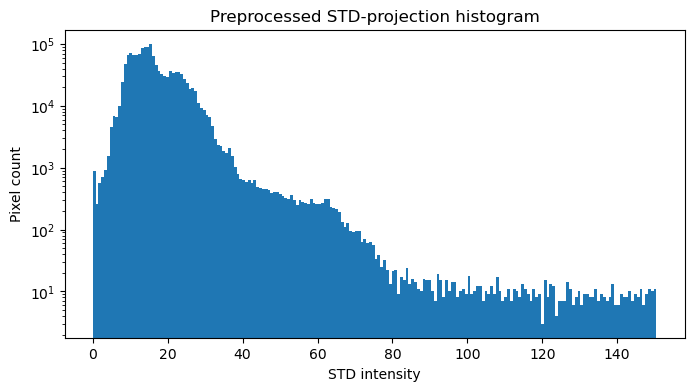

In [17]:
# Save the STD projection locally and check its intensity distribution.
import tifffile

PROJECTIONS_DIR = Path("/Users/leolopster/Desktop/spike_inference/_projections")
PROJECTIONS_DIR.mkdir(exist_ok=True)

dataset_tag = data_dir.name.split("-")[0]  # "Debi_DRG" from "Debi_DRG-Streamtodisk-...imgdir"
std_projection_path = PROJECTIONS_DIR / f"{dataset_tag}_std_projection.tiff"

tifffile.imwrite(std_projection_path, preprocessed_std_stack)
print(f"> Saved STD projection -> {std_projection_path}")

# QC: pixel-intensity distribution, used to pick contrast/threshold before
# manually painting ROIs on top of this layer.
plt.figure(figsize=(8, 4))
plt.hist(preprocessed_std_stack.ravel(), bins=200)
plt.yscale('log')
plt.xlabel("STD intensity")
plt.ylabel("Pixel count")
plt.title("Preprocessed STD-projection histogram")
plt.show()

ii. Load in the ROI mask on top of the stacked image

In [18]:
# Shared ROI-mask I/O settings for the create / load / save cells below.
LABELS_DIR = Path("/Users/leolopster/Desktop/spike_inference/_labels")
LABELS_DIR.mkdir(exist_ok=True)

# Base image layer whose shape/scale/translate the ROI Labels layer must match.
# "preprocessed_std" (temporal fluctuation) drives ROI drawing better than the
# max projection; swap here if you prefer another layer.
REFERENCE_IMAGE_LAYER = "preprocessed_std"

# Default load/save path, following the existing `_labels/<name>_ROI.tiff` convention.
ROI_MASK_PATH = LABELS_DIR / f"{dataset_tag}_ROI.tiff"

**(a) Create a new blank ROI Labels layer** — paint ROIs by hand with napari's brush tool.

In [20]:
# (a) Create a blank Labels layer sized to the reference image, then paint
# ROIs onto it with the napari brush tool (press `m` for a fresh label id
# per ROI). Run this OR the load cell below -- not both.
ref_layer = viewer.layers[REFERENCE_IMAGE_LAYER]
ref_shape = ref_layer.data.shape[-2:]

blank_mask = np.zeros(ref_shape, dtype=np.uint16)

roi_labels = viewer.add_labels(
    blank_mask,
    name="ROI mask",
    opacity=0.6,
    scale=tuple(np.atleast_1d(getattr(ref_layer, "scale", (1, 1)))[-2:]),
    translate=tuple(np.atleast_1d(getattr(ref_layer, "translate", (0, 0)))[-2:]),
)
print(f"> Created blank 'ROI mask' ({ref_shape[0]}x{ref_shape[1]}) matching "
      f"'{REFERENCE_IMAGE_LAYER}' -- paint ROIs with the brush tool.")

> Created blank 'ROI mask' (1024x1376) matching 'preprocessed_std' -- paint ROIs with the brush tool.


**(b) Load an existing ROI mask (`.tiff`)** — reads a rasterised Labels mask from disk and overlays it on the reference layer.

In [21]:
# (b) Load an existing ROI mask. Default location:
#     /Users/leolopster/Desktop/spike_inference/_labels/<dataset_tag>_ROI.tiff
mask = tifffile.imread(ROI_MASK_PATH)
print(f"> Loaded mask {mask.shape} {mask.dtype} from {ROI_MASK_PATH}; "
      f"{len(np.unique(mask)) - 1} ROI(s) found")

ref_layer = viewer.layers[REFERENCE_IMAGE_LAYER]
ref_shape = ref_layer.data.shape[-2:]
if mask.shape != ref_shape:
    raise ValueError(
        f"Loaded mask shape {mask.shape} != '{REFERENCE_IMAGE_LAYER}' shape {ref_shape}; "
        "check ROI_MASK_PATH / REFERENCE_IMAGE_LAYER."
    )

roi_labels = viewer.add_labels(
    mask.astype(np.uint16),
    name="ROI mask",
    opacity=0.6,
    scale=tuple(np.atleast_1d(getattr(ref_layer, "scale", (1, 1)))[-2:]),
    translate=tuple(np.atleast_1d(getattr(ref_layer, "translate", (0, 0)))[-2:]),
)

> Loaded mask (1024, 1376) uint16 from /Users/leolopster/Desktop/spike_inference/_labels/Debi_DRG_ROI.tiff; 40 ROI(s) found


**(c) Save the current ROI Labels layer** — writes the painted/edited mask back to `ROI_MASK_PATH`.

In [22]:
# (c) Save the current ROI Labels layer back to disk as a .tiff.
roi_labels = viewer.layers["ROI mask"]  # the Labels layer created/edited above

tifffile.imwrite(ROI_MASK_PATH, roi_labels.data.astype(np.uint16))
print(f"> Saved 'ROI mask' ({roi_labels.data.shape}, "
      f"{len(np.unique(roi_labels.data)) - 1} ROI(s)) -> {ROI_MASK_PATH}")

> Saved 'ROI mask' ((1024, 1376), 40 ROI(s)) -> /Users/leolopster/Desktop/spike_inference/_labels/Debi_DRG_ROI.tiff


iii. Create brightness traces along the time axis for each ROI, based on `preprocessed_stack`

In [23]:
# Real per-frame acquisition times (seconds) from the .imgdir metadata, used as
# the shared time axis for every trace plot below. ElapsedTimes.yaml stores a
# list whose first entry is the frame count, followed by one elapsed time (ms)
# per frame.
import yaml

with open(data_dir / "ElapsedTimes.yaml") as f:
    _elapsed = yaml.safe_load(f)["theElapsedTimes"]

times_ms = np.asarray(_elapsed[1:], dtype=float)  # drop leading count entry
n_timepoints = preprocessed_stack.shape[0]
if len(times_ms) != n_timepoints:
    # Fall back to a nominal 10 Hz axis if metadata length disagrees with the stack.
    print(f"! ElapsedTimes has {len(times_ms)} entries but stack has {n_timepoints} frames; "
          "falling back to a nominal 10 Hz time axis.")
    times_s = np.arange(n_timepoints, dtype=float) / 10.0
else:
    times_s = (times_ms - times_ms[0]) / 1000.0

print(f"> Time axis: {n_timepoints} frames, {times_s[-1]:.1f} s total, "
      f"~{1.0 / np.median(np.diff(times_s)):.1f} Hz median")

> Time axis: 3220 frames, 322.2 s total, ~10.0 Hz median


In [24]:
# Per-ROI mean-intensity (brightness) trace over the full time axis, streamed
# one dask frame at a time so the whole (n_timepoints, H, W) float32 stack is
# never materialised in RAM at once.
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable


def extract_roi_traces(stack, mask):
    """Return {roi_id: (n_timepoints,) float32 mean-intensity trace}."""
    n_t = stack.shape[0]
    roi_ids = [int(r) for r in np.unique(mask) if r != 0]
    # Precompute pixel indices per ROI once -- avoids re-masking every frame.
    roi_indices = {roi_id: np.where(mask == roi_id) for roi_id in roi_ids}
    traces = {roi_id: np.zeros(n_t, dtype=np.float32) for roi_id in roi_ids}

    for t in tqdm(range(n_t), desc="Extracting ROI traces"):
        frame = np.asarray(stack[t])  # materialise exactly one frame
        for roi_id in roi_ids:
            yy, xx = roi_indices[roi_id]
            traces[roi_id][t] = frame[yy, xx].mean()
    return traces


roi_mask = viewer.layers["ROI mask"].data
roi_traces = extract_roi_traces(preprocessed_stack, roi_mask)
print(f"> Extracted {len(roi_traces)} ROI traces ({n_timepoints} timepoints each)")

Extracting ROI traces: 100%|██████████| 3220/3220 [00:16<00:00, 190.51it/s]

> Extracted 40 ROI traces (3220 timepoints each)


iv. Create dF/F (F: brightness) traces for each ROI from obtained brightness traces

In [25]:
# dF/F per ROI using a rolling low-percentile baseline (CLAUDE.md 3): F0(t) is
# the BASELINE_PERCENTILE-th percentile of the ROI's own trace over a sliding
# ~BASELINE_WINDOW_S window, so slow drift / photobleaching across the ~5 min
# recording is tracked rather than baked into a single fixed baseline.
from scipy.ndimage import percentile_filter

BASELINE_PERCENTILE = 8   # low percentile approximates the inactive-baseline level
BASELINE_WINDOW_S = 45    # rolling window length (s)


def compute_dff(trace, times_s, percentile=BASELINE_PERCENTILE, window_s=BASELINE_WINDOW_S):
    dt = np.median(np.diff(times_s))
    win = max(3, int(round(window_s / dt)))
    f0 = percentile_filter(trace, percentile=percentile, size=win, mode="nearest")
    # preprocessed traces are background-subtracted + clipped at 0, so F0 can sit
    # near zero; floor it to keep dF/F finite.
    f0 = np.clip(f0, 1e-3, None)
    return (trace - f0) / f0


roi_ids = sorted(roi_traces)
dff_traces = {roi_id: compute_dff(roi_traces[roi_id], times_s) for roi_id in roi_ids}
dff_matrix = np.vstack([dff_traces[roi_id] for roi_id in roi_ids])  # (n_rois, n_timepoints)
print(f"> Computed dF/F for {len(roi_ids)} ROI(s); "
      f"dF/F range [{dff_matrix.min():.2f}, {dff_matrix.max():.2f}]")


> Computed dF/F for 40 ROI(s); dF/F range [-1.00, 11.33]


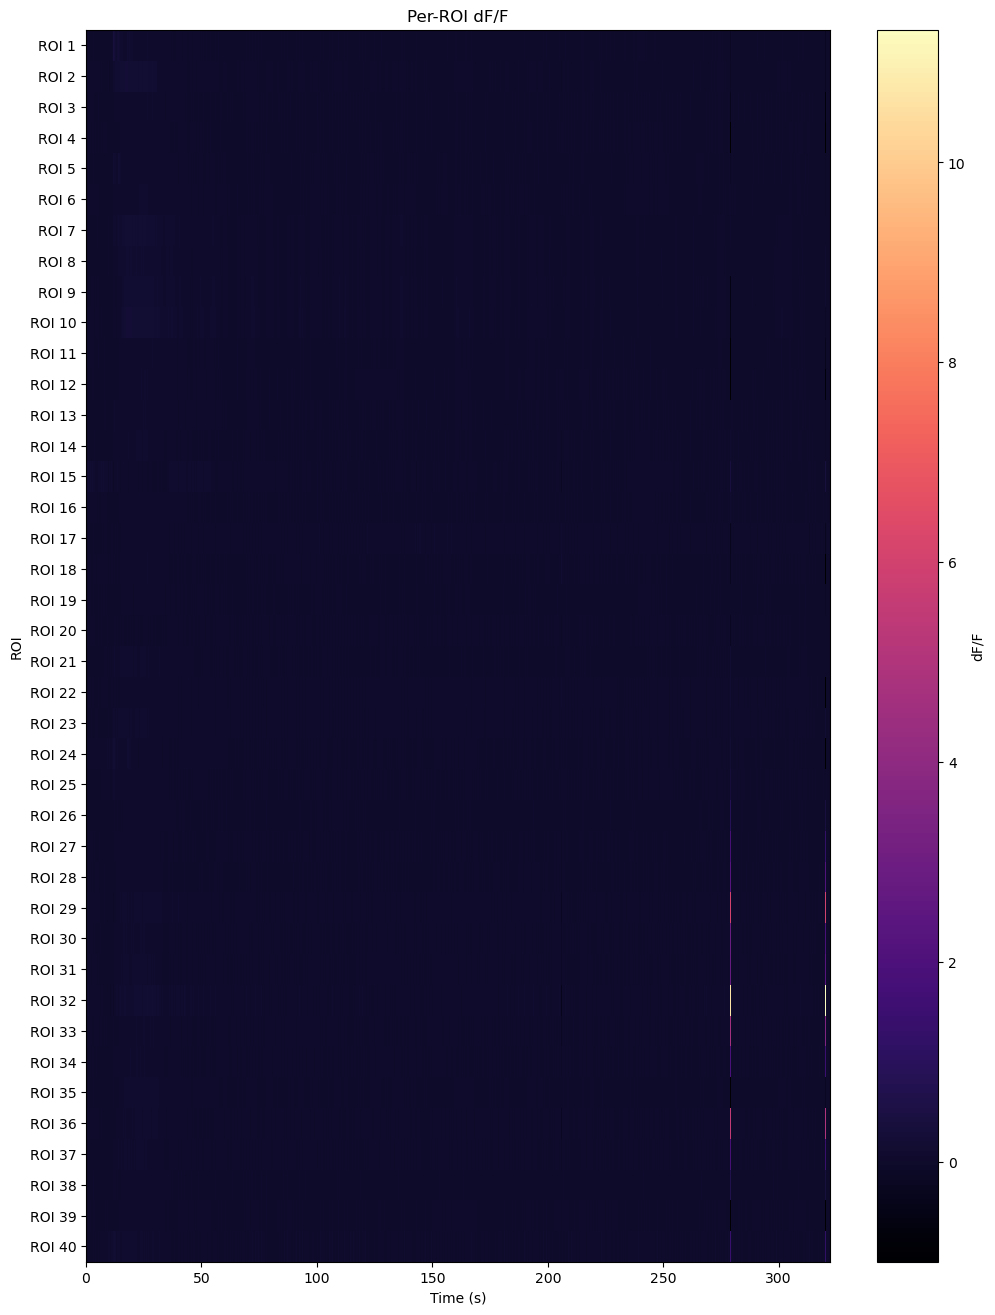

In [26]:
# QC plot A -- dF/F spectrograph: one row per ROI, x = time (s), pixel = dF/F.
# magma (perceptually uniform) per CLAUDE.md 5; jet is avoided.
fig, ax = plt.subplots(figsize=(12, 0.35 * len(roi_ids) + 2))
im = ax.imshow(
    dff_matrix,
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    extent=[times_s[0], times_s[-1], len(roi_ids) - 0.5, -0.5],
)
ax.set_yticks(range(len(roi_ids)))
ax.set_yticklabels([f"ROI {r}" for r in roi_ids])
ax.set_xlabel("Time (s)")
ax.set_ylabel("ROI")
ax.set_title("Per-ROI dF/F")
fig.colorbar(im, ax=ax, label="dF/F")
plt.show()


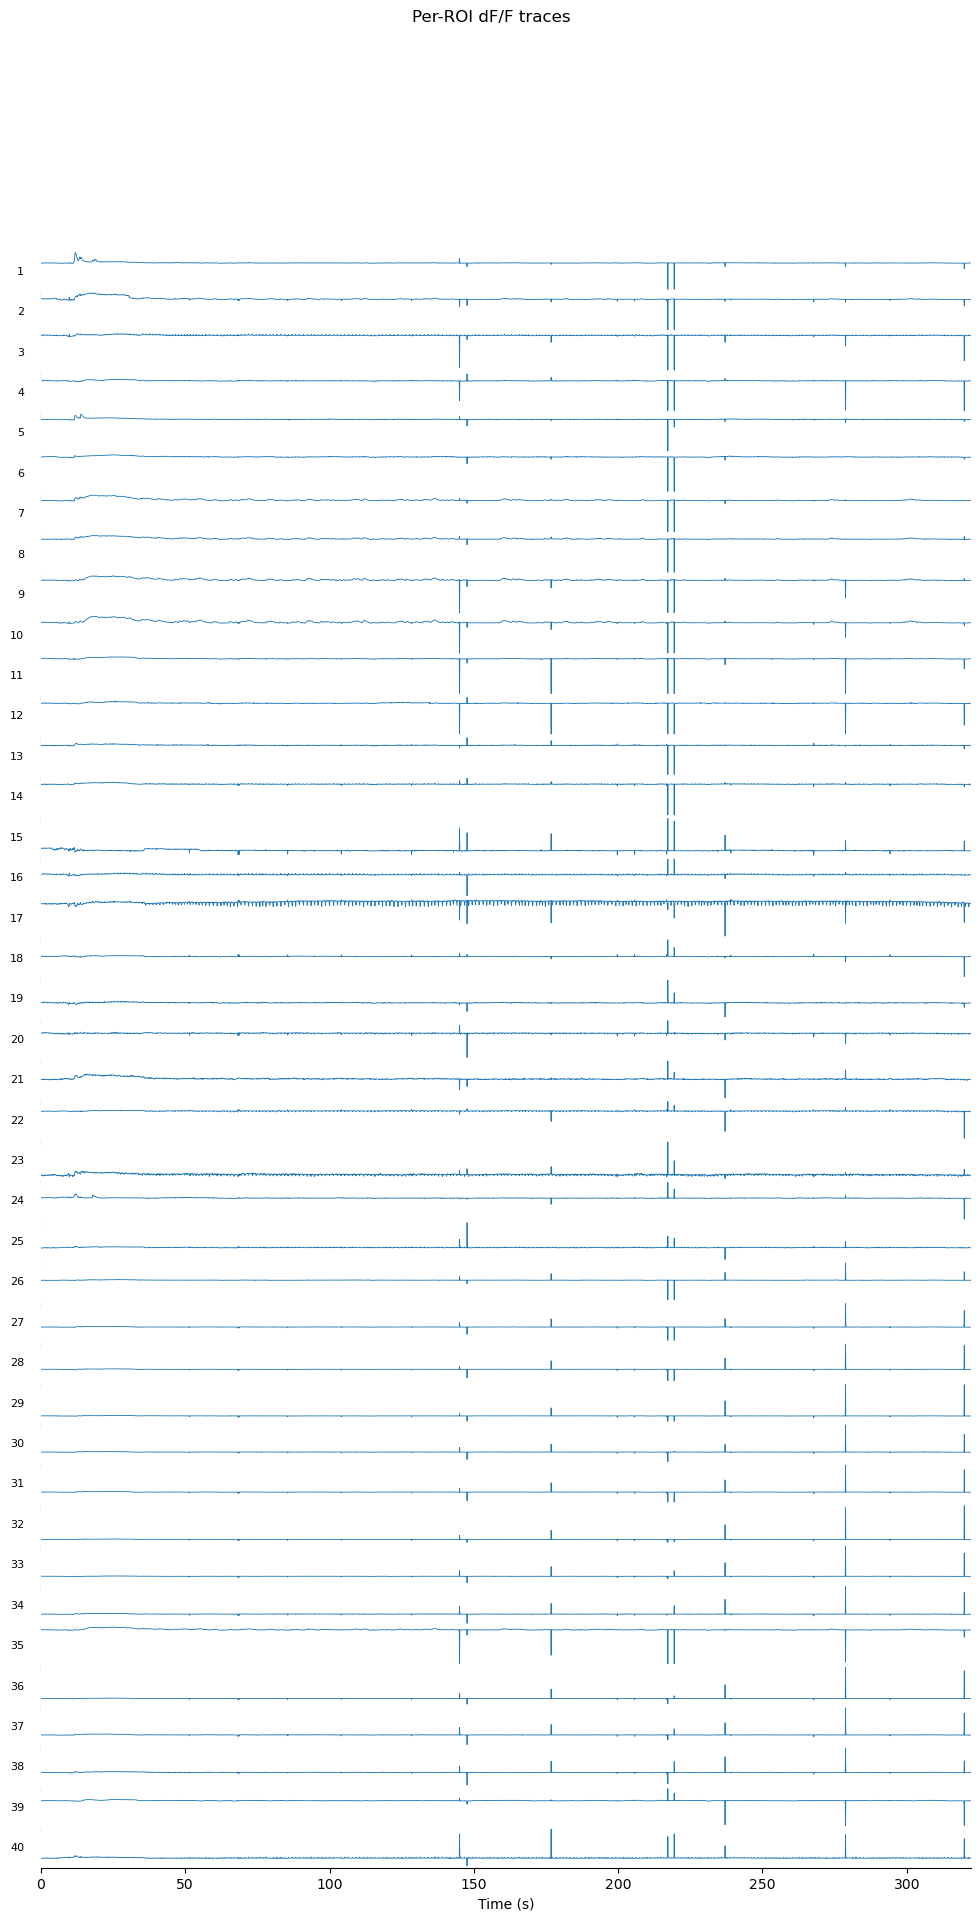

In [27]:
# QC plot B -- stacked dF/F line charts: one subplot per ROI, tightly stacked,
# trace only (no grid, no spines/ticks), ROI number in the left padding.
n_rois = len(roi_ids)
fig, axes = plt.subplots(
    n_rois, 1, sharex=True, figsize=(12, 0.5 * n_rois + 1),
)
axes = np.atleast_1d(axes)
fig.subplots_adjust(hspace=0)

for ax, roi_id in zip(axes, roi_ids):
    ax.plot(times_s, dff_traces[roi_id], linewidth=0.6)
    ax.margins(x=0)
    ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_ylabel(str(roi_id), rotation=0, ha="right", va="center", labelpad=12, fontsize=8)

# only the bottom subplot carries the shared time axis
axes[-1].spines["bottom"].set_visible(True)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Per-ROI dF/F traces", y=0.995)
plt.show()


v. Summarize dF/F and group traces by PCA

vi. Create a non-directional weighted graph with ROI as nodes and the distance on PCA as edges. Sort nodes by distance.